# Data stats


In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import ticker
import matplotlib.image as mpimg

from sdss.metadata import MetaData
from anomaly.utils import specobjid_to_idx

meta = MetaData()

# Custom functions

# Directories

In [2]:
thesis_dir = "/home/elom/phd/thesis"
ch_3_dir = f"{thesis_dir}/chapters/03_figures"

data_dir = "/home/elom/phd/code/spectra"
bin_id_list = [f'bin_{i:02d}' for i in range(4)]
bin_id_list

['bin_00', 'bin_01', 'bin_02', 'bin_03']

# Data ingestion

In [3]:
wave_interp_grid = np.linspace(3500, 7500, 4000)

wave = np.load(f"{data_dir}/wave_spectra_imputed.npy")

interp_spectra = np.load(
    f"{data_dir}/interpolated_spectra.npy",
    mmap_mode="r"
)

spectra = np.load(
    f"{data_dir}/spectra_imputed.npy",
    mmap_mode="r"
)
interp_spectra.shape, spectra.shape

((791738, 4000), (728133, 3773))

In [4]:
sdss_dr16_df = pd.read_csv(
    f"{data_dir}/meta_data/sdss_dr16.csv.gz",
    index_col="specobjid",
)

meta_data_df = pd.read_csv(
    f"{data_dir}/0_01_z_0_5_4_0_snr_inf.csv.gz",
    index_col="specobjid",
)

drop_meta_data_df = pd.read_csv(
    f"{data_dir}/drop_0_01_z_0_5_4_0_snr_inf.csv.gz",
    index_col="specobjid",
)

final_meta_data_df = pd.read_csv(
    f"{data_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

In [5]:
meta_data_df.shape, drop_meta_data_df.shape, final_meta_data_df.shape

((791738, 21), (728133, 21), (727401, 22))

In [6]:
final_meta_data_df.plate.unique().max()

2974

In [7]:
final_meta_data_df.instrument.unique()

array(['SDSS'], dtype=object)

In [8]:
final_meta_data_df.programname.unique()

array(['perseus', 'legacy', 'southern', 'preboss', 'lowz_lrg',
       'reddening', 'lowz', 'm31_fstars', 'photoz',
       'premarvels_preselection', 'orion', 'fstars', 'lowz_loveday',
       'apbias'], dtype=object)

In [9]:
final_meta_data_df.targetType.unique()

array(['SCIENCE'], dtype=object)

# Original metadata

In [10]:
sdss_dr16_df[['z', 'snMedian']].describe()

,z,snMedian
count,1.230784e+06,1.230784e+06
mean,2.500505e-01,1.294168e+01
std,5.845417e-01,9.979355e+00
min,-1.144691e-02,0.000000e+00
25%,4.136888e-02,6.169225e+00
50%,1.043898e-01,1.124805e+01
75%,1.907414e-01,1.674395e+01
max,7.010272e+00,1.190490e+02


In [11]:
meta_data_df[['z', 'snMedian']].describe()

,z,snMedian
count,791738.000000,791738.000000
mean,0.126654,14.029552
std,0.078947,7.188912
min,0.010000,4.000041
25%,0.072437,9.155969
50%,0.110189,12.641005
75%,0.158063,17.079265
max,0.499533,98.104000


# Inputting

## Spec removal

In [12]:
n_nan_spec_interp = np.count_nonzero(
    ~np.isfinite(interp_spectra), axis=1
)
# ------------------------------------------------
drop_fraction = 0.1
number_waves = interp_spectra.shape[1]
drop_threshold = number_waves * drop_fraction

print(f"Drop threshold: {drop_threshold}")
# ------------------------------------------------
keep_spectra_mask = n_nan_spec_interp < drop_threshold
n_keep_spec = np.sum(keep_spectra_mask)
n_drop_spec = np.sum(~keep_spectra_mask)
print(f"Number of kept spectra: {n_keep_spec}")
print(f"Number of dropped spectra: {n_drop_spec}")
# ------------------------------------------------

Drop threshold: 400.0
Number of kept spectra: 728133
Number of dropped spectra: 63605


/tmp/ipykernel_385340/1817383327.py:14: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 5_000_000)


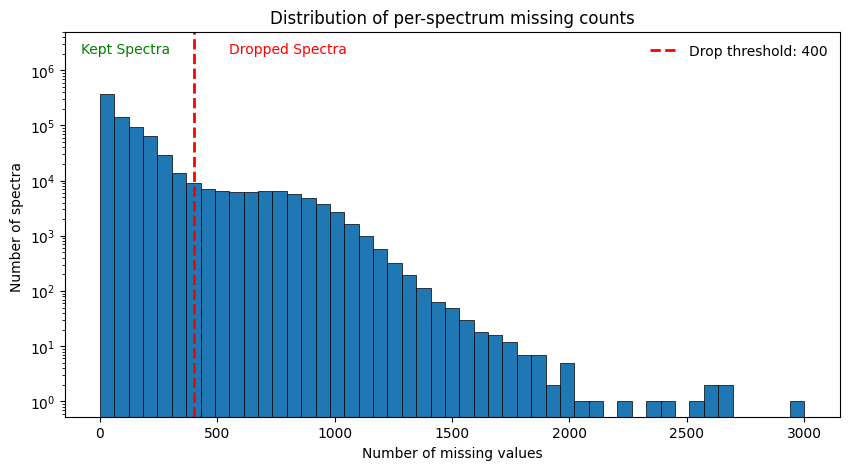

In [15]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

_ = ax.hist(
    n_nan_spec_interp,
    bins=np.linspace(0, 3001, 50),
    color='tab:blue', edgecolor='black',
    linewidth=0.5
    # bins=list(range(0, 401, 100)) + list(range(400, 3001, 100)),
    # range=(0, np.nanmax(n_nan_spec_interp))
)
ax.set_yscale('log')
ax.set_ylim(0, 5_000_000)

# horizontal line for drop threshold
ax.axvline(
    x=400,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Drop threshold: 400'
)

ax.text(
    400 * 0.275,
    ax.get_ylim()[1] * 0.4,
    'Kept Spectra', 
    color='green', ha='center', fontsize=10
)

ax.text(
    400 * 2,
    ax.get_ylim()[1] * 0.4,
    'Dropped Spectra', 
    color='red', ha='center', fontsize=10
)
ax.legend(frameon=False)
ax.set_title('Distribution of per-spectrum missing counts')
ax.set_xlabel('Number of missing values')
ax.set_ylabel("Number of spectra ")
# save figure
fig.savefig(
    f"{ch_3_dir}/per_spec_indefinite_counts.pdf",
    bbox_inches='tight'
)

## Flux removal

In [14]:
kept_spectra = interp_spectra[keep_spectra_mask]

n_nan_wave_interp = np.count_nonzero(
    ~np.isfinite(kept_spectra), axis=0
)
# ------------------------------------------------
drop_fraction = 0.1
number_spectra = kept_spectra.shape[0]
drop_threshold = number_spectra * drop_fraction

print(f"Drop threshold: {drop_threshold}")
# ------------------------------------------------
keep_wave_mask = n_nan_wave_interp < drop_threshold
n_keep_wave = np.sum(keep_wave_mask)
n_drop_wave = np.sum(~keep_wave_mask)
print(f"Number of kept waves: {n_keep_wave}")
print(f"Number of dropped waves: {n_drop_wave}")
# ------------------------------------------------

Drop threshold: 72813.3
Number of kept waves: 3773
Number of dropped waves: 227


/tmp/ipykernel_385340/2869145386.py:11: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 1_000_000)


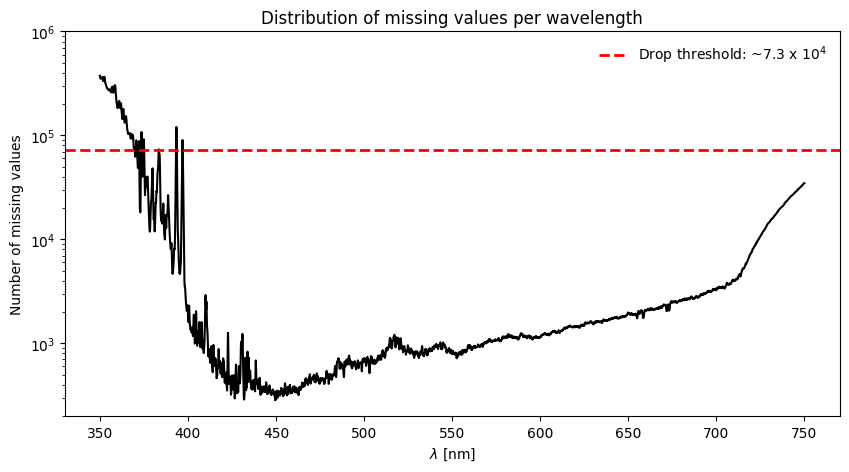

In [16]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.plot(
    wave_interp_grid*0.1,
    n_nan_wave_interp,
    color='black', 
)
ax.set_yscale('log')
ax.set_ylim(0, 1_000_000)

# horizontal line for drop threshold
ax.axhline(
    y=drop_threshold,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Drop threshold: ~{drop_threshold*0.0001:.1f} x $10^4$'
)

ax.set_xlabel(r'$\lambda$ [nm]')
ax.set_ylabel("Number of missing values")
ax.legend(frameon=False)

# ax.set_ylabel(r'Count ($\times 10^3$)')
ax.set_title('Distribution of missing values per wavelength')
# save figure
fig.savefig(
    f"{ch_3_dir}/per_wave_indefinite_counts.pdf",
    bbox_inches='tight'
)

# Overall stats

## z and S/N

In [17]:
final_meta_data_df[['z', 'snMedian']].describe()

,z,snMedian
count,727401.000000,727401.000000
mean,0.111644,14.674778
std,0.055971,7.028271
min,0.010000,4.000447
25%,0.070380,9.941226
50%,0.104716,13.150480
75%,0.145947,17.543710
max,0.298085,94.130220


## SDSS classification

In [18]:
final_meta_data_df.subClass.value_counts(dropna=False).to_clipboard()
final_meta_data_df.subClass.value_counts(dropna=False)

subClass
NaN                      422780
STARFORMING              223314
STARBURST                 53539
AGN                       15126
BROADLINE                  9691
AGN BROADLINE              1882
STARFORMING BROADLINE       988
STARBURST BROADLINE          81
Name: count, dtype: int64

## z and S/N accross bins

In [19]:
z_bins_dict = {}
snMedian_bins_dict = {}
bin_class_dict = {}

for bin_id in bin_id_list:

    idx_id_bin = np.load(
        f"{data_dir}/{bin_id}/{bin_id}_index_specobjid.npy"
    )

    bin_df = final_meta_data_df.loc[idx_id_bin[:, 1]].copy()

    z_bins_dict[bin_id] = bin_df.z.describe()
    snMedian_bins_dict[bin_id] = bin_df.snMedian.describe()
    bin_class_dict[bin_id] = bin_df.subClass.value_counts(dropna=False)

z_accross_bins_df = pd.concat(
    z_bins_dict.values(), 
    axis=1, 
    keys=z_bins_dict.keys()
)

snMedian_accross_bins_df = pd.concat(
    snMedian_bins_dict.values(), 
    axis=1, 
    keys=snMedian_bins_dict.keys()
)

In [20]:
# snMedian_accross_bins_df.to_clipboard()
snMedian_accross_bins_df

,bin_00,bin_01,bin_02,bin_03
count,181850.000000,181850.000000,181850.000000,181850.000000
mean,7.825193,11.545665,15.118417,24.209400
std,1.477449,0.916465,1.248192,6.719912
min,4.000447,9.941226,13.150480,17.543710
25%,6.805009,10.759805,14.029790,19.383460
50%,8.073803,11.543760,15.011820,22.073380
75%,9.062627,12.332928,16.147098,26.834085
max,9.941210,13.150480,17.543690,92.638030


In [21]:
z_accross_bins_df.to_clipboard()
z_accross_bins_df

,bin_00,bin_01,bin_02,bin_03
count,181850.000000,181850.000000,181850.000000,181850.000000
mean,0.128536,0.126533,0.111300,0.080209
std,0.068583,0.054145,0.045028,0.037052
min,0.010000,0.010006,0.010000,0.010013
25%,0.073508,0.085036,0.078506,0.052717
50%,0.120308,0.125167,0.109953,0.076443
75%,0.177222,0.163464,0.140810,0.103513
max,0.298085,0.297165,0.297462,0.294866


## Class accross bins

In [22]:
bin_class_accross_bins_df = pd.DataFrame(bin_class_dict)
bin_class_accross_bins_df, bin_class_dict['bin_00']

(                       bin_00  bin_01  bin_02  bin_03
 subClass                                             
 AGN                      1647    2955    4080    6444
 AGN BROADLINE              85     212     336    1249
 BROADLINE                 134     393     960    8203
 STARBURST               18133   13156   12200   10050
 STARBURST BROADLINE        21      22      23      15
 STARFORMING             73240   60868   50742   38464
 STARFORMING BROADLINE      62     133     189     604
 NaN                     88528  104111  113320  116821,
 subClass
 NaN                      88528
 STARFORMING              73240
 STARBURST                18133
 AGN                       1647
 BROADLINE                  134
 AGN BROADLINE               85
 STARFORMING BROADLINE       62
 STARBURST BROADLINE         21
 Name: count, dtype: int64)

In [23]:
bin_class_accross_bins_df.sort_index()

,bin_00,bin_01,bin_02,bin_03
subClass,,,,
AGN,1647,2955,4080,6444
AGN BROADLINE,85,212,336,1249
BROADLINE,134,393,960,8203
STARBURST,18133,13156,12200,10050
STARBURST BROADLINE,21,22,23,15
STARFORMING,73240,60868,50742,38464
STARFORMING BROADLINE,62,133,189,604
NaN,88528,104111,113320,116821


In [24]:
all_bins_classes = [bin_class_dict[bin_id] for bin_id in bin_id_list]
# [bin_00_class, bin_01_class, bin_02_class, bin_03_new_class]

classes_df = pd.concat(
    all_bins_classes, 
    axis=1, 
    keys=['bin0', 'bin1', 'bin2', 'bin3']
)
classes_df.to_clipboard()
classes_df


,bin0,bin1,bin2,bin3
subClass,,,,
NaN,88528,104111,113320,116821
STARFORMING,73240,60868,50742,38464
STARBURST,18133,13156,12200,10050
AGN,1647,2955,4080,6444
BROADLINE,134,393,960,8203
AGN BROADLINE,85,212,336,1249
STARFORMING BROADLINE,62,133,189,604
STARBURST BROADLINE,21,22,23,15


# Histograms final data

In [25]:
bin_df_dict = {}

bin_id_list = ['bin_00', 'bin_01', 'bin_02', 'bin_03']

for bin_id in bin_id_list:

    idx_id_bin = np.load(
        f"{data_dir}/{bin_id}/{bin_id}_index_specobjid.npy"
    )

    bin_df_dict[bin_id] = final_meta_data_df.loc[idx_id_bin[:, 1]].copy()

## redshift

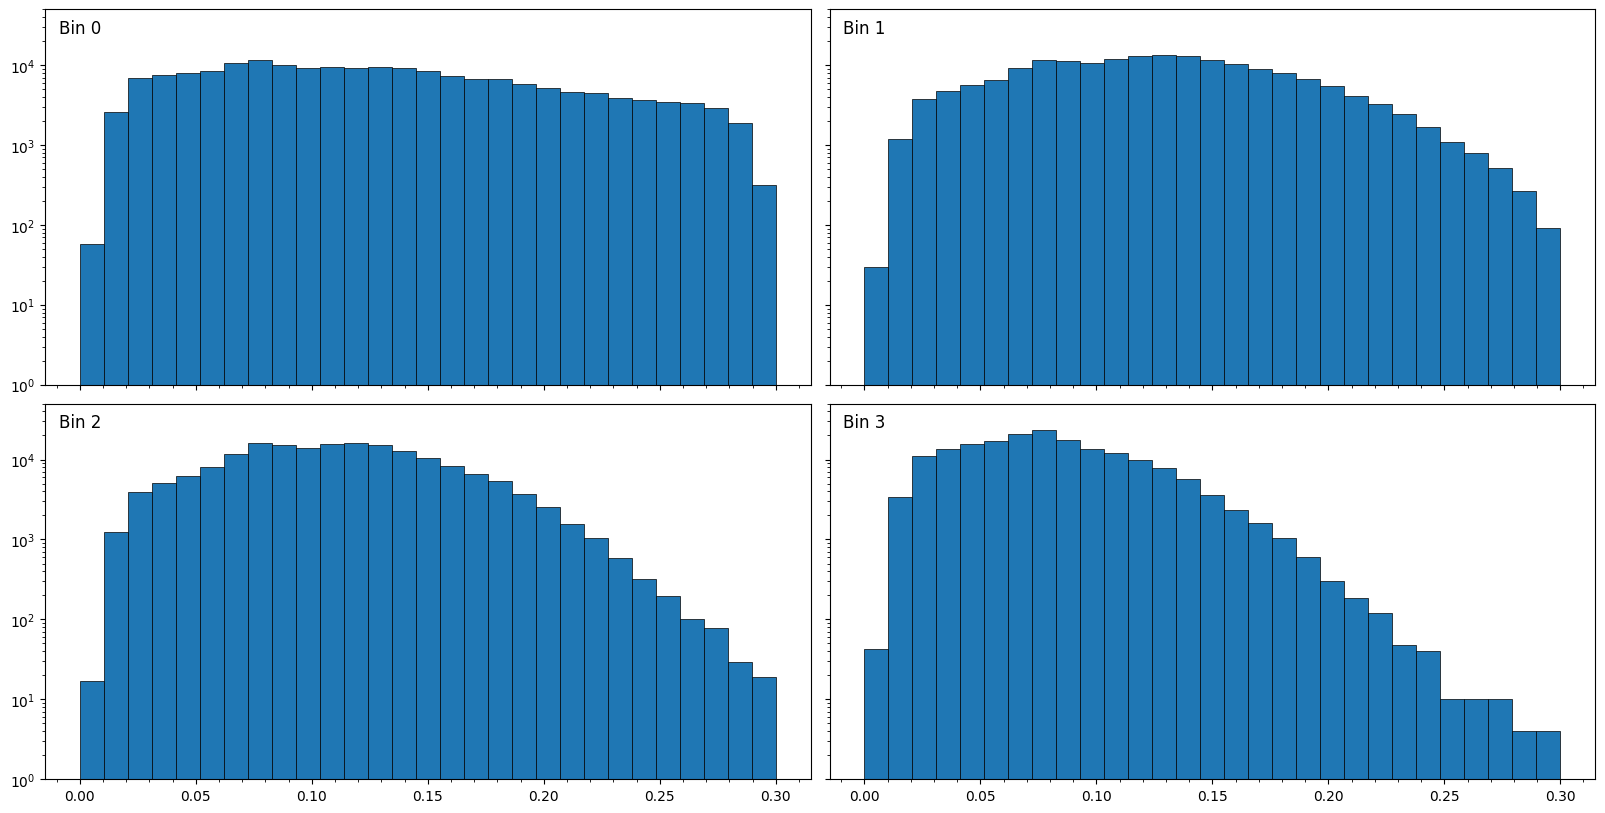

In [26]:
z_00 = bin_df_dict['bin_00']['z']
z_01 = bin_df_dict['bin_01']['z']
z_02 = bin_df_dict['bin_02']['z']
z_03 = bin_df_dict['bin_03']['z']
bin_space = np.linspace(0, 0.3, 30)
# -------------------------------------------
fig, axs = plt.subplots(
    2, 2,
    sharex=True,
    sharey=True,
    figsize=(20, 10)
)

# -------------------------------------------
_ = axs[0, 0].hist(
    z_00,
    bins=bin_space,
    color='tab:blue', edgecolor='black',
    linewidth=0.5
)
axs[0, 0].text(
    0, 25_000,
    'Bin 0', 
    color='black', ha='center', fontsize=12
)
# -------------------------------------------
_ = axs[0, 1].hist(
    z_01,
    bins=bin_space,
    color='tab:blue', edgecolor='black',
    linewidth=0.5
)
axs[0, 1].text(
    0, 25_000,
    'Bin 1', 
    color='black', ha='center', fontsize=12
)
# -------------------------------------------
_ = axs[1, 0].hist(
    z_02,
    bins=bin_space,
    color='tab:blue', edgecolor='black',
    linewidth=0.5
)

axs[1, 0].text(
    0, 25_000,
    'Bin 2', 
    color='black', ha='center', fontsize=12
)
# -------------------------------------------
_ = axs[1, 1].hist(
    z_03,
    bins=bin_space,
    color='tab:blue', edgecolor='black',
    linewidth=0.5
)

axs[1, 1].text(
    0, 25_000,
    'Bin 3', 
    color='black', ha='center', fontsize=12
)
# -------------------------------------------
for ax in axs.flatten():
    ax.set_ylim(1, 50_000)
    ax.set_yscale('log')
    ax.minorticks_on()
    # ax.legend(frameon=False)

# adjust vertical space
plt.subplots_adjust(
    hspace=0.05,
    wspace=0.025
)
# ax.set_title('Distribution of per-spectrum indefinite counts')
# ax.set_xlabel('Number of indefinite values')
# ax.set_ylabel("Number of spectra - log scale)")

# # save figure
# fig.savefig(
#     f"{ch_3_dir}/",
#     bbox_inches='tight'
# )

## S/N

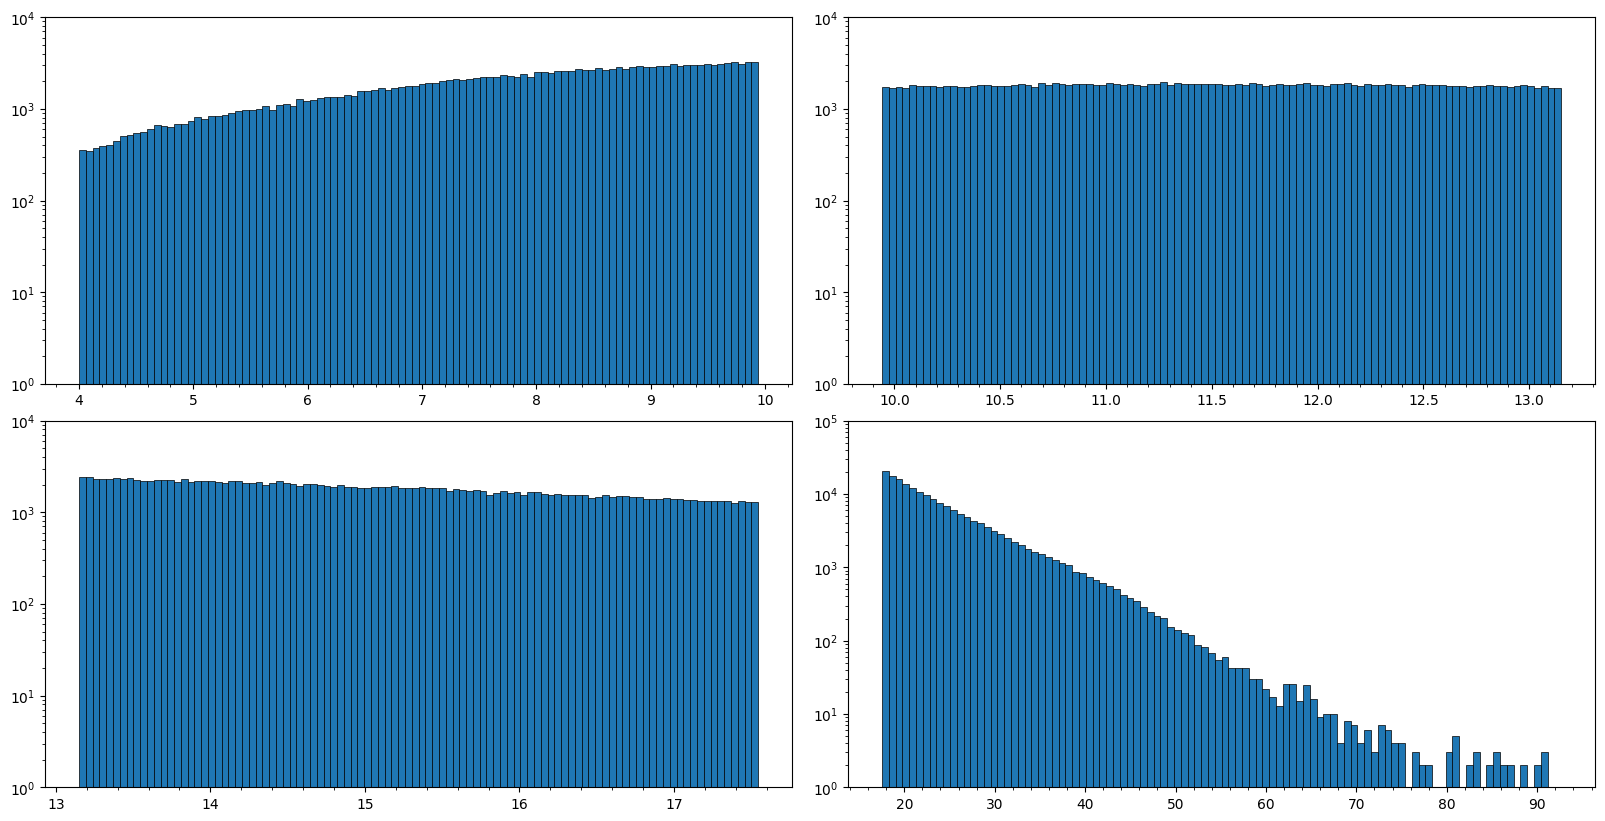

In [27]:
sn_00 = bin_df_dict['bin_00']['snMedian']
sn_01 = bin_df_dict['bin_01']['snMedian']
sn_02 = bin_df_dict['bin_02']['snMedian']
sn_03 = bin_df_dict['bin_03']['snMedian']
n_bins = 100
# -------------------------------------------
fig, axs = plt.subplots(
    2, 2,
    figsize=(20, 10)
)

# -------------------------------------------
_ = axs[0, 0].hist(
    sn_00,
    bins=n_bins,
    color='tab:blue', edgecolor='black',
    linewidth=0.5
)
axs[0, 0].set_ylim(1, 10_000)

# axs[0, 0].text(
#     0, 25_000,
#     'Bin 0', 
#     color='black', ha='center', fontsize=12
# )
# -------------------------------------------
_ = axs[0, 1].hist(
    sn_01,
    bins=n_bins,
    color='tab:blue', edgecolor='black',
    linewidth=0.5
)
axs[0, 1].set_ylim(1, 10_000)

# axs[0, 1].text(
#     0, 25_000,
#     'Bin 1', 
#     color='black', ha='center', fontsize=12
# )
# -------------------------------------------
_ = axs[1, 0].hist(
    sn_02,
    bins=n_bins,
    color='tab:blue', edgecolor='black',
    linewidth=0.5
)
axs[1, 0].set_ylim(1, 10_000)

# axs[1, 0].text(
#     0, 25_000,
#     'Bin 2', 
#     color='black', ha='center', fontsize=12
# )
# -------------------------------------------
_ = axs[1, 1].hist(
    sn_03,
    bins=n_bins,
    color='tab:blue', edgecolor='black',
    linewidth=0.5
)
axs[1, 1].set_ylim(1, 100_000)

# axs[1, 1].text(
#     0, 25_000,
#     'Bin 3', 
#     color='black', ha='center', fontsize=12
# )
# -------------------------------------------
for ax in axs.flatten():
    ax.set_yscale('log')
    ax.minorticks_on()
    # ax.legend(frameon=False)

# adjust vertical space
plt.subplots_adjust(
    hspace=0.1,
    wspace=0.075
)
# ax.set_title('Distribution of per-spectrum indefinite counts')
# ax.set_xlabel('Number of indefinite values')
# ax.set_ylabel("Number of spectra - log scale)")

# # save figure
# fig.savefig(
#     f"{ch_3_dir}/",
#     bbox_inches='tight'
# )

## ebv

In [28]:
# use this df because it is before imputting
meta_data_df.ebv.describe()

count    791738.000000
mean          0.028965
std           0.021745
min           0.002540
25%           0.016017
50%           0.023777
75%           0.035354
max           1.381049
Name: ebv, dtype: float64

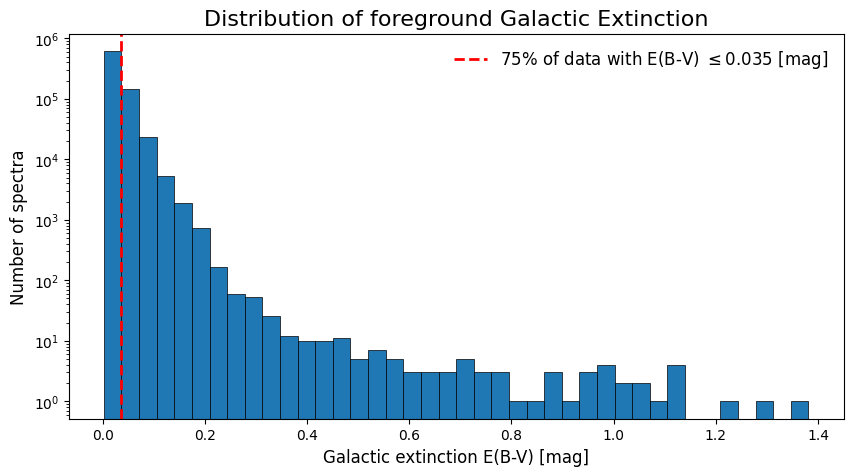

In [31]:
fig, ax = plt.subplots(
    1, 1,
    figsize=(10, 5)
)
_ = ax.hist(
    meta_data_df.ebv,
    bins=40,
    color='tab:blue', edgecolor='black',
    linewidth=0.5
)
ax.set_yscale('log')

ax.set_xlabel("Galactic extinction E(B-V) [mag]", fontsize=12)
ax.set_ylabel("Number of spectra", fontsize=12)
ax.set_title("Distribution of foreground Galactic Extinction", fontsize=16)

ebv_75 = 0.035354
ax.axvline(
    ebv_75, 
    color='red', 
    linestyle='--', 
    linewidth=2, 
    label=r'75% of data with E(B-V) $\leq 0.035$ [mag]'
)
ax.legend(fontsize=12, frameon=False)

fig.savefig(
    f"{ch_3_dir}/ebv_distribution.pdf",
    bbox_inches='tight'
)

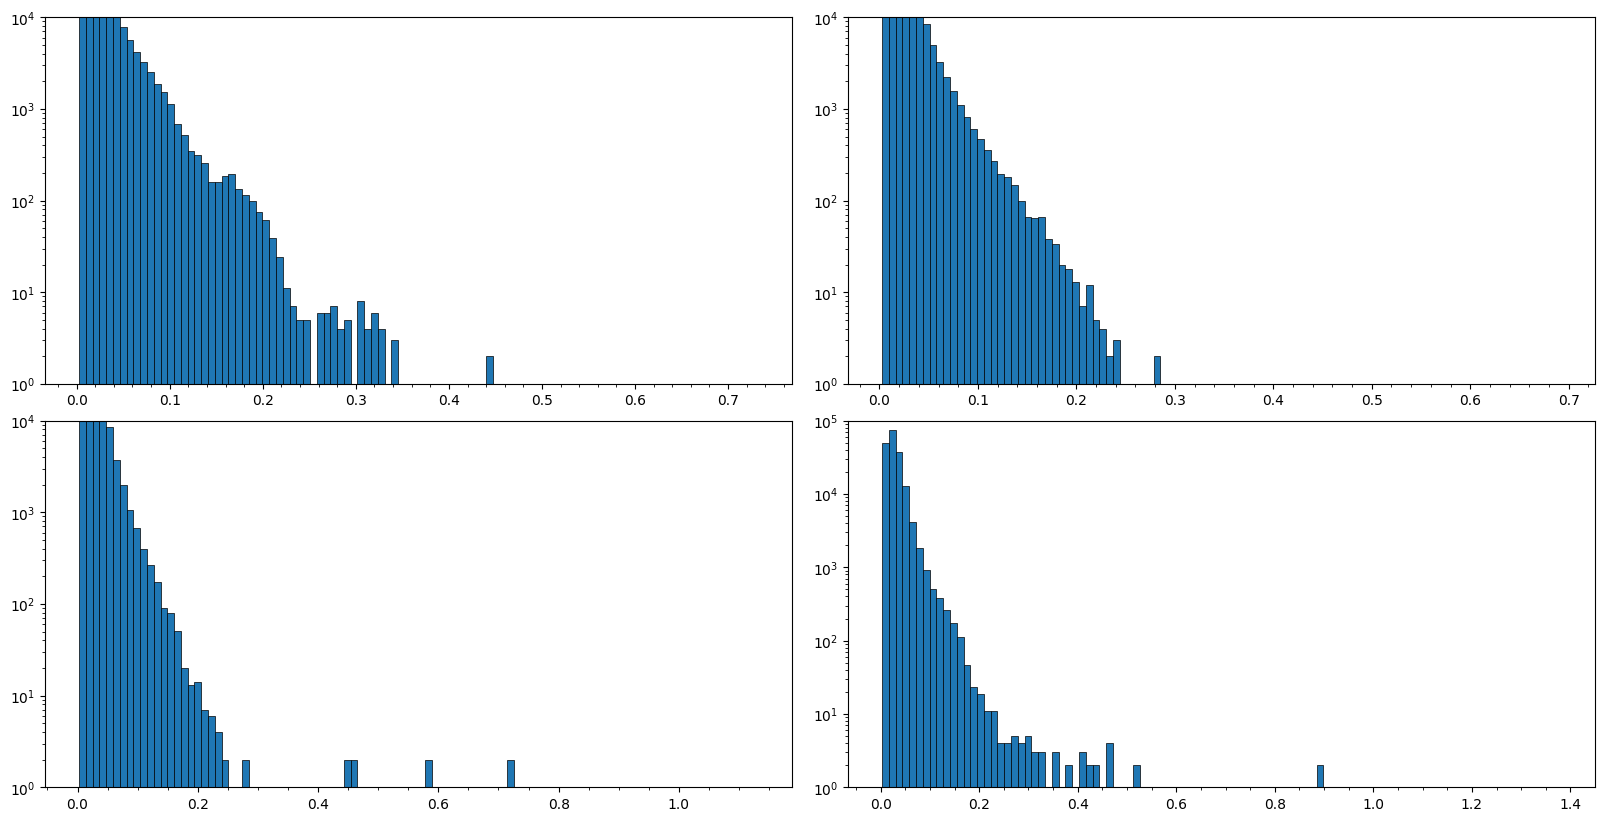

In [32]:
ebv_00 = bin_df_dict['bin_00']['ebv']
ebv_01 = bin_df_dict['bin_01']['ebv']
ebv_02 = bin_df_dict['bin_02']['ebv']
ebv_03 = bin_df_dict['bin_03']['ebv']
n_bins = 100
# -------------------------------------------
fig, axs = plt.subplots(
    2, 2,
    figsize=(20, 10)
)

# -------------------------------------------
_ = axs[0, 0].hist(
    ebv_00,
    bins=n_bins,
    color='tab:blue', edgecolor='black',
    linewidth=0.5
)
axs[0, 0].set_ylim(1, 10_000)

# axs[0, 0].text(
#     0, 25_000,
#     'Bin 0', 
#     color='black', ha='center', fontsize=12
# )
# -------------------------------------------
_ = axs[0, 1].hist(
    ebv_01,
    bins=n_bins,
    color='tab:blue', edgecolor='black',
    linewidth=0.5
)
axs[0, 1].set_ylim(1, 10_000)

# axs[0, 1].text(
#     0, 25_000,
#     'Bin 1', 
#     color='black', ha='center', fontsize=12
# )
# -------------------------------------------
_ = axs[1, 0].hist(
    ebv_02,
    bins=n_bins,
    color='tab:blue', edgecolor='black',
    linewidth=0.5
)
axs[1, 0].set_ylim(1, 10_000)

# axs[1, 0].text(
#     0, 25_000,
#     'Bin 2', 
#     color='black', ha='center', fontsize=12
# )
# -------------------------------------------
_ = axs[1, 1].hist(
    ebv_03,
    bins=n_bins,
    color='tab:blue', edgecolor='black',
    linewidth=0.5
)
axs[1, 1].set_ylim(1, 100_000)

# axs[1, 1].text(
#     0, 25_000,
#     'Bin 3', 
#     color='black', ha='center', fontsize=12
# )
# -------------------------------------------
for ax in axs.flatten():
    ax.set_yscale('log')
    ax.minorticks_on()
    # ax.legend(frameon=False)

# adjust vertical space
plt.subplots_adjust(
    hspace=0.1,
    wspace=0.075
)
# ax.set_title('Distribution of per-spectrum indefinite counts')
# ax.set_xlabel('Number of indefinite values')
# ax.set_ylabel("Number of spectra - log scale)")

# # save figure
# fig.savefig(
#     f"{ch_3_dir}/",
#     bbox_inches='tight'
# )